In [15]:
import geopandas as gpd
from shapely.geometry import box, Polygon

In [16]:
gdf = gpd.read_file("./resources/FAO_fishing_areas/FAO_AREAS_ERASE_LOWRES.json")
print(gdf.crs)

EPSG:4326


min_lon: -69.61  min_lat: -60.0  max_lon: -50.0  max_lat: -40.0


<Axes: >

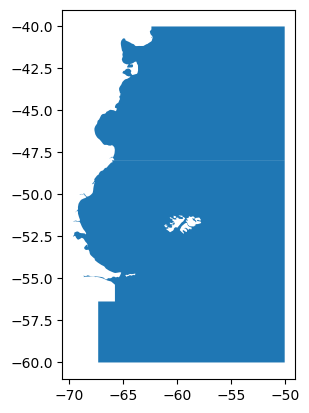

In [17]:
FAO_41 = gdf[gdf['F_AREA'] == '41']
FAO_41_Sub_32_31_23 = FAO_41[FAO_41['F_DIVISION'].isin(['41.3.2', '41.3.1'])]

bbox = FAO_41_Sub_32_31_23.total_bounds.round(2)
min_lon, min_lat, max_lon, max_lat = bbox
print("min_lon:", min_lon, 
      " min_lat:", min_lat, 
      " max_lon:", max_lon, 
      " max_lat:", max_lat)

FAO_41_Sub_32_31_23.plot()


EPSG:4326


<Axes: >

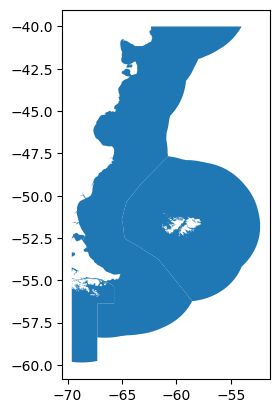

In [18]:
eez = gpd.read_file("./resources/Marine_Regions/World_EEZ_v12/eez_v12.shp", bbox=tuple(bbox))
print(eez.crs) 
bbox_geom = box(*bbox)
eez_clipped = gpd.clip(eez, bbox_geom)
eez_clipped.plot()


In [19]:
eez_falk = eez_clipped[eez_clipped['GEONAME'] == "Overlapping claim Falkland / Malvinas Islands: United Kingdom / Argentina"]
eez_no_falk = eez_clipped[eez_clipped['GEONAME'] != "Overlapping claim Falkland / Malvinas Islands: United Kingdom / Argentina"].copy()
fao_minus_eez = gpd.overlay(FAO_41_Sub_32_31_23, eez_no_falk, how='difference')

In [20]:
land_polygons = gpd.read_file("./resources/OpenStreet_features/land-polygons-complete-4326/land_polygons.shp", bbox=tuple(bbox))
land_clipped = gpd.clip(land_polygons, bbox_geom)

In [21]:
buffer_m = 12 * 1852 #12 millas nauticas, no queremos aguas territoriales
land_buffer = (land_clipped
               .to_crs(epsg=3857)            # metric for buffering
               .geometry
               .buffer(buffer_m))            # buffer in meters

land_buffer_gdf = gpd.GeoDataFrame(geometry=land_buffer, crs="EPSG:3857").to_crs(epsg=4326) #le aplicamos el buffer y lo conertimos de nuevo a WGS84

<Axes: >

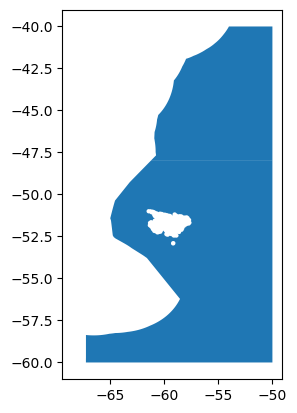

In [22]:

available_fishing_area = gpd.overlay(fao_minus_eez, land_buffer_gdf, how='difference') #area disponible para pesca internacional
available_fishing_area.plot()

In [23]:
# project to meters
gdf = gdf.to_crs(epsg=3857)

# simplify (example: 100 m tolerance)
gdf["geometry"] = gdf.geometry.simplify(
    tolerance=100,
    preserve_topology=True
)

# back to lat/lon if needed
gdf = gdf.to_crs(epsg=4326)

gdf.to_file("./data/SWA_land_simplified.geojson", driver="GeoJSON")

In [24]:
available_fishing_area_geom = available_fishing_area.union_all()  # This creates a single shapely geometry
land_clipped_geom = land_clipped.union_all()
# Create a new GeoDataFrame with the merged geometry
available_fishing_area_gdf = gpd.GeoDataFrame(geometry=[available_fishing_area_geom], crs=gdf.crs)
land_clipped_gdf = gpd.GeoDataFrame(geometry=[land_clipped_geom], crs=gdf.crs)

#the land dataframe is very high resoluton, we lower down resolution to 7000m
land_clipped_gdf = land_clipped_gdf.to_crs(epsg=3857)
# simplify 
land_clipped_gdf["geometry"] = land_clipped_gdf.geometry.simplify(
    tolerance=7000,
    preserve_topology=False
)
# back to the original projection
land_clipped_gdf = land_clipped_gdf.to_crs(epsg=4326)


In [25]:
available_fishing_area_gdf.to_file("./data/available_SWA_fishing_area.geojson", driver="GeoJSON")
land_clipped_gdf.to_file("./data/SWA_land.geojson", driver="GeoJSON")

<Axes: >

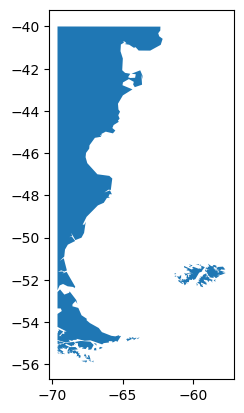

In [26]:
land_clipped_gdf.plot()

In [27]:
eez_falk["outer_border"] = eez_falk.geometry.apply(
    lambda geom: Polygon(geom.exterior)
)
eez_fk_outer = eez_falk.set_geometry("outer_border").drop(columns="geometry")
eez_fk_outer.to_file("./data/eez_fk.geojson", driver="GeoJSON")

c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


C:\Users\rubar\AppData\Local\Temp\ipykernel_12868\4208503793.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered_gdf["geometry"] = buffered_gdf.geometry.buffer(res)


<Axes: >

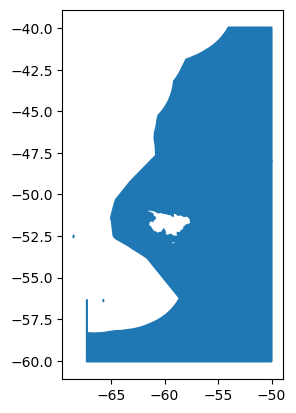

In [28]:

buffered_gdf = available_fishing_area.copy()
res = 0.1
buffered_gdf["geometry"] = buffered_gdf.geometry.buffer(res)
buffered_gdf.to_file(f"./data/available_SWA_fishing_area_buffered_{res}.geojson", driver="GeoJSON")
buffered_gdf.plot()

In [ ]:
### Area de pesca de la flota española en aguas internacionales